# Data Exploration for Carbon Flux Quantification

**Purpose:** Exploratory data analysis of EC tower measurements from 7 European sites

**Author:** Paul Ezennolim  
**Thesis:** Temporal-spatial data fusion for carbon flux quatification in agroecosystems: a multimodal learning approach

---

**Sites:**
- Training (5): FI-Lom, GL-ZaF, IE-Cra, DE-Akm, FR-LGt
- Test (2): UK-AMo, SE-Htm

**Target variable:** NEE_VUT_REF (Net Ecosystem Exchange)

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import os
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

if 'Carbon-flux-quatification' in os.getcwd():
    # Find the project root
    PROJECT_ROOT = Path(os.getcwd().split('Carbon-flux-quatification')[0]) / 'Carbon-flux-quatification'
else:
    PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
FIG_DIR = PROJECT_ROOT / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Setup complete.')
print(f'  Data: {DATA_DIR}') 

Setup complete.
  Data: /Users/paulezennolim/Downloads/Carbon-flux-quatification/data/raw


## 1. Loading EC Tower Data

Loading measurements from 7 European eddy covariance flux towers spanning wetland, cropland, and forest ecosystems.

In [12]:
# Define sites
sites = {
    'FI-Lom': ('1.FI-Lom.csv', 'Lompolojankka', 'Finland', 'Wetland', 'Training'),
    'GL-ZaF': ('2.GL-ZaF.csv', 'Zackenberg Fen', 'Greenland', 'Wetland', 'Training'),
    'IE-Cra': ('3.IE-Cra.xlsx', 'Crogen', 'Ireland', 'Cropland', 'Training'),
    'DE-Akm': ('4.DE-Akm.csv', 'Anklam', 'Germany', 'Wetland', 'Training'),
    'FR-LGt': ('5.FR-LGt.csv', 'Laignes', 'France', 'Cropland', 'Training'),
    'UK-AMo': ('6.UK-AMo.csv', 'Auchencorth Moss', 'UK', 'Wetland', 'Test'),
    'SE-Htm': ('7.SE-Htm.csv', 'Hyltemossa', 'Sweden', 'Forest', 'Test'),
}

# Load all sites
data = {}
for code, (file, name, country, ecosystem, split) in sites.items():
    filepath = DATA_DIR / file
    if filepath.suffix == '.xlsx':
        df = pd.read_excel(filepath)
    else:
        df = pd.read_csv(filepath)

    # Parse timestamp
    ts_col = 'TIMESTAMP' if 'TIMESTAMP' in df.columns else 'timestamp'
    df[ts_col] = pd.to_datetime(df[ts_col], dayfirst=True)
    df = df.rename(columns={ts_col: 'TIMESTAMP'}).set_index('TIMESTAMP')

    data[code] = {
        'df': df,
        'name': name,
        'country': country,
        'ecosystem': ecosystem,
        'split': split,
    }

    print(f"{code} ({ecosystem:>8s}): {len(df):>6,} records, "
          f"{df.shape[1]:>2} columns, {split} set")

FI-Lom ( Wetland):  5,349 records, 32 columns, Training set
GL-ZaF ( Wetland):  2,790 records, 32 columns, Training set
IE-Cra (Cropland):  8,783 records, 32 columns, Training set
DE-Akm ( Wetland):  3,837 records, 32 columns, Training set
FR-LGt (Cropland):  5,295 records, 32 columns, Training set
UK-AMo ( Wetland):  9,486 records, 32 columns, Test set
SE-Htm (  Forest):  5,438 records, 32 columns, Test set


## 2. Data Quality Assessment

Check for missing values and data completeness across sites.

In [13]:
# Create summary table
summary_rows = []
for code, info in data.items():
    df = info['df']

    nee_missing = df['NEE_VUT_REF'].isna().sum() if 'NEE_VUT_REF' in df.columns else 0
    nee_pct = (nee_missing / len(df)) * 100
    total_missing_pct = df.isna().sum().sum() / df.size * 100

    summary_rows.append({
        'Site': code,
        'Name': info['name'],
        'Ecosystem': info['ecosystem'],
        'Split': info['split'],
        'Records': f"{len(df):,}",
        'Columns': df.shape[1],
        'NEE Missing': f"{nee_missing:,} ({nee_pct:.1f}%)",
        'Overall Missing': f"{total_missing_pct:.1f}%",
        'Start': df.index.min().strftime('%Y-%m-%d'),
        'End': df.index.max().strftime('%Y-%m-%d'),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,Site,Name,Ecosystem,Split,Records,Columns,NEE Missing,Overall Missing,Start,End
0,FI-Lom,Lompolojankka,Wetland,Training,"5,349",32,0 (0.0%),32.7%,2009-02-21,2009-10-20
1,GL-ZaF,Zackenberg Fen,Wetland,Training,"2,790",32,0 (0.0%),48.2%,2011-05-01,2011-10-10
2,IE-Cra,Crogen,Cropland,Training,"8,783",32,158 (1.8%),46.2%,2020-01-01,2020-12-31
3,DE-Akm,Anklam,Wetland,Training,"3,837",32,0 (0.0%),40.6%,2020-03-25,2020-10-07
4,FR-LGt,Laignes,Cropland,Training,"5,295",32,0 (0.0%),34.7%,2022-01-01,2022-11-02
5,UK-AMo,Auchencorth Moss,Wetland,Test,"9,486",32,0 (0.0%),30.1%,2021-11-16,2022-12-31
6,SE-Htm,Hyltemossa,Forest,Test,"5,438",32,67 (1.2%),27.7%,2016-01-01,2016-08-14


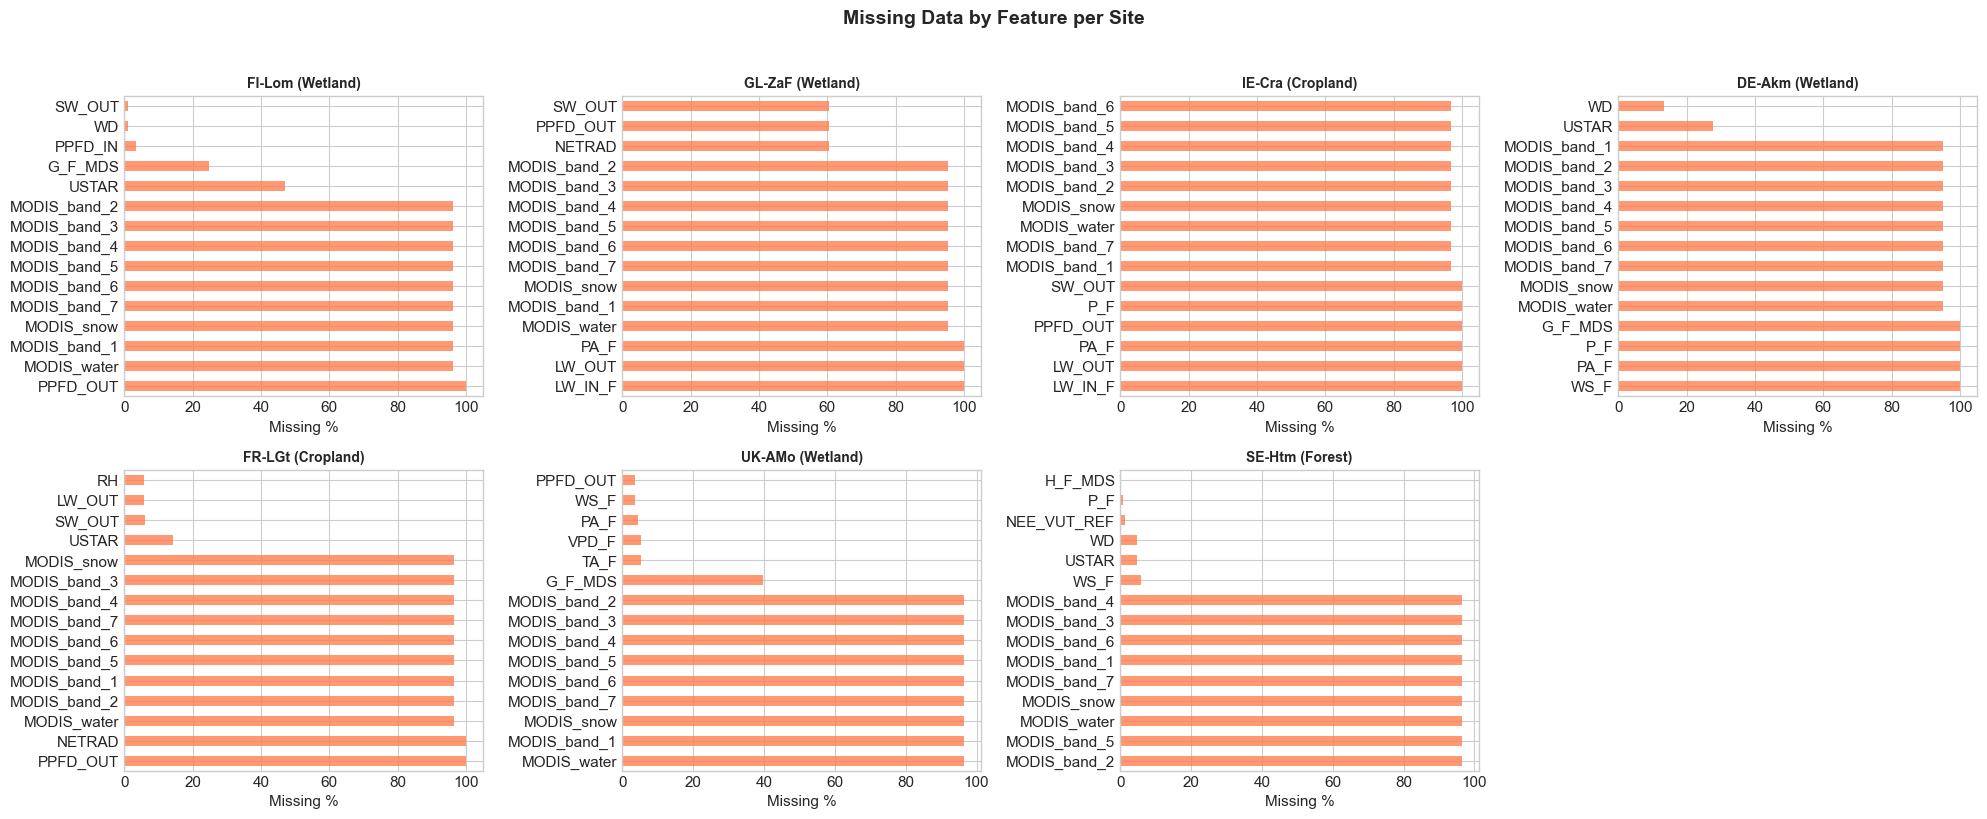

Figure saved: missing_data_by_site.png


In [14]:
# Missing data heatmap
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for idx, (code, info) in enumerate(data.items()):
    df = info['df']
    ax = axes[idx]

    missing_pct = df.isna().mean() * 100
    cols_with_missing = missing_pct[missing_pct > 0].sort_values(ascending=False)

    if len(cols_with_missing) > 0:
        cols_with_missing.head(15).plot.barh(ax=ax, color='coral', alpha=0.8)
        ax.set_xlabel('Missing %')
    else:
        ax.text(0.5, 0.5, 'No missing\ndata', ha='center', va='center',
                transform=ax.transAxes, fontsize=12)

    ax.set_title(f"{code} ({info['ecosystem']})", fontsize=10, fontweight='bold')

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle('Missing Data by Feature per Site', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'missing_data_by_site.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: missing_data_by_site.png')

## 3. NEE Time Series for All Sites

Visualizing net ecosystem exchange across all 7 sites. NEE < 0 indicates carbon uptake (photosynthesis), NEE > 0 indicates carbon release (respiration).

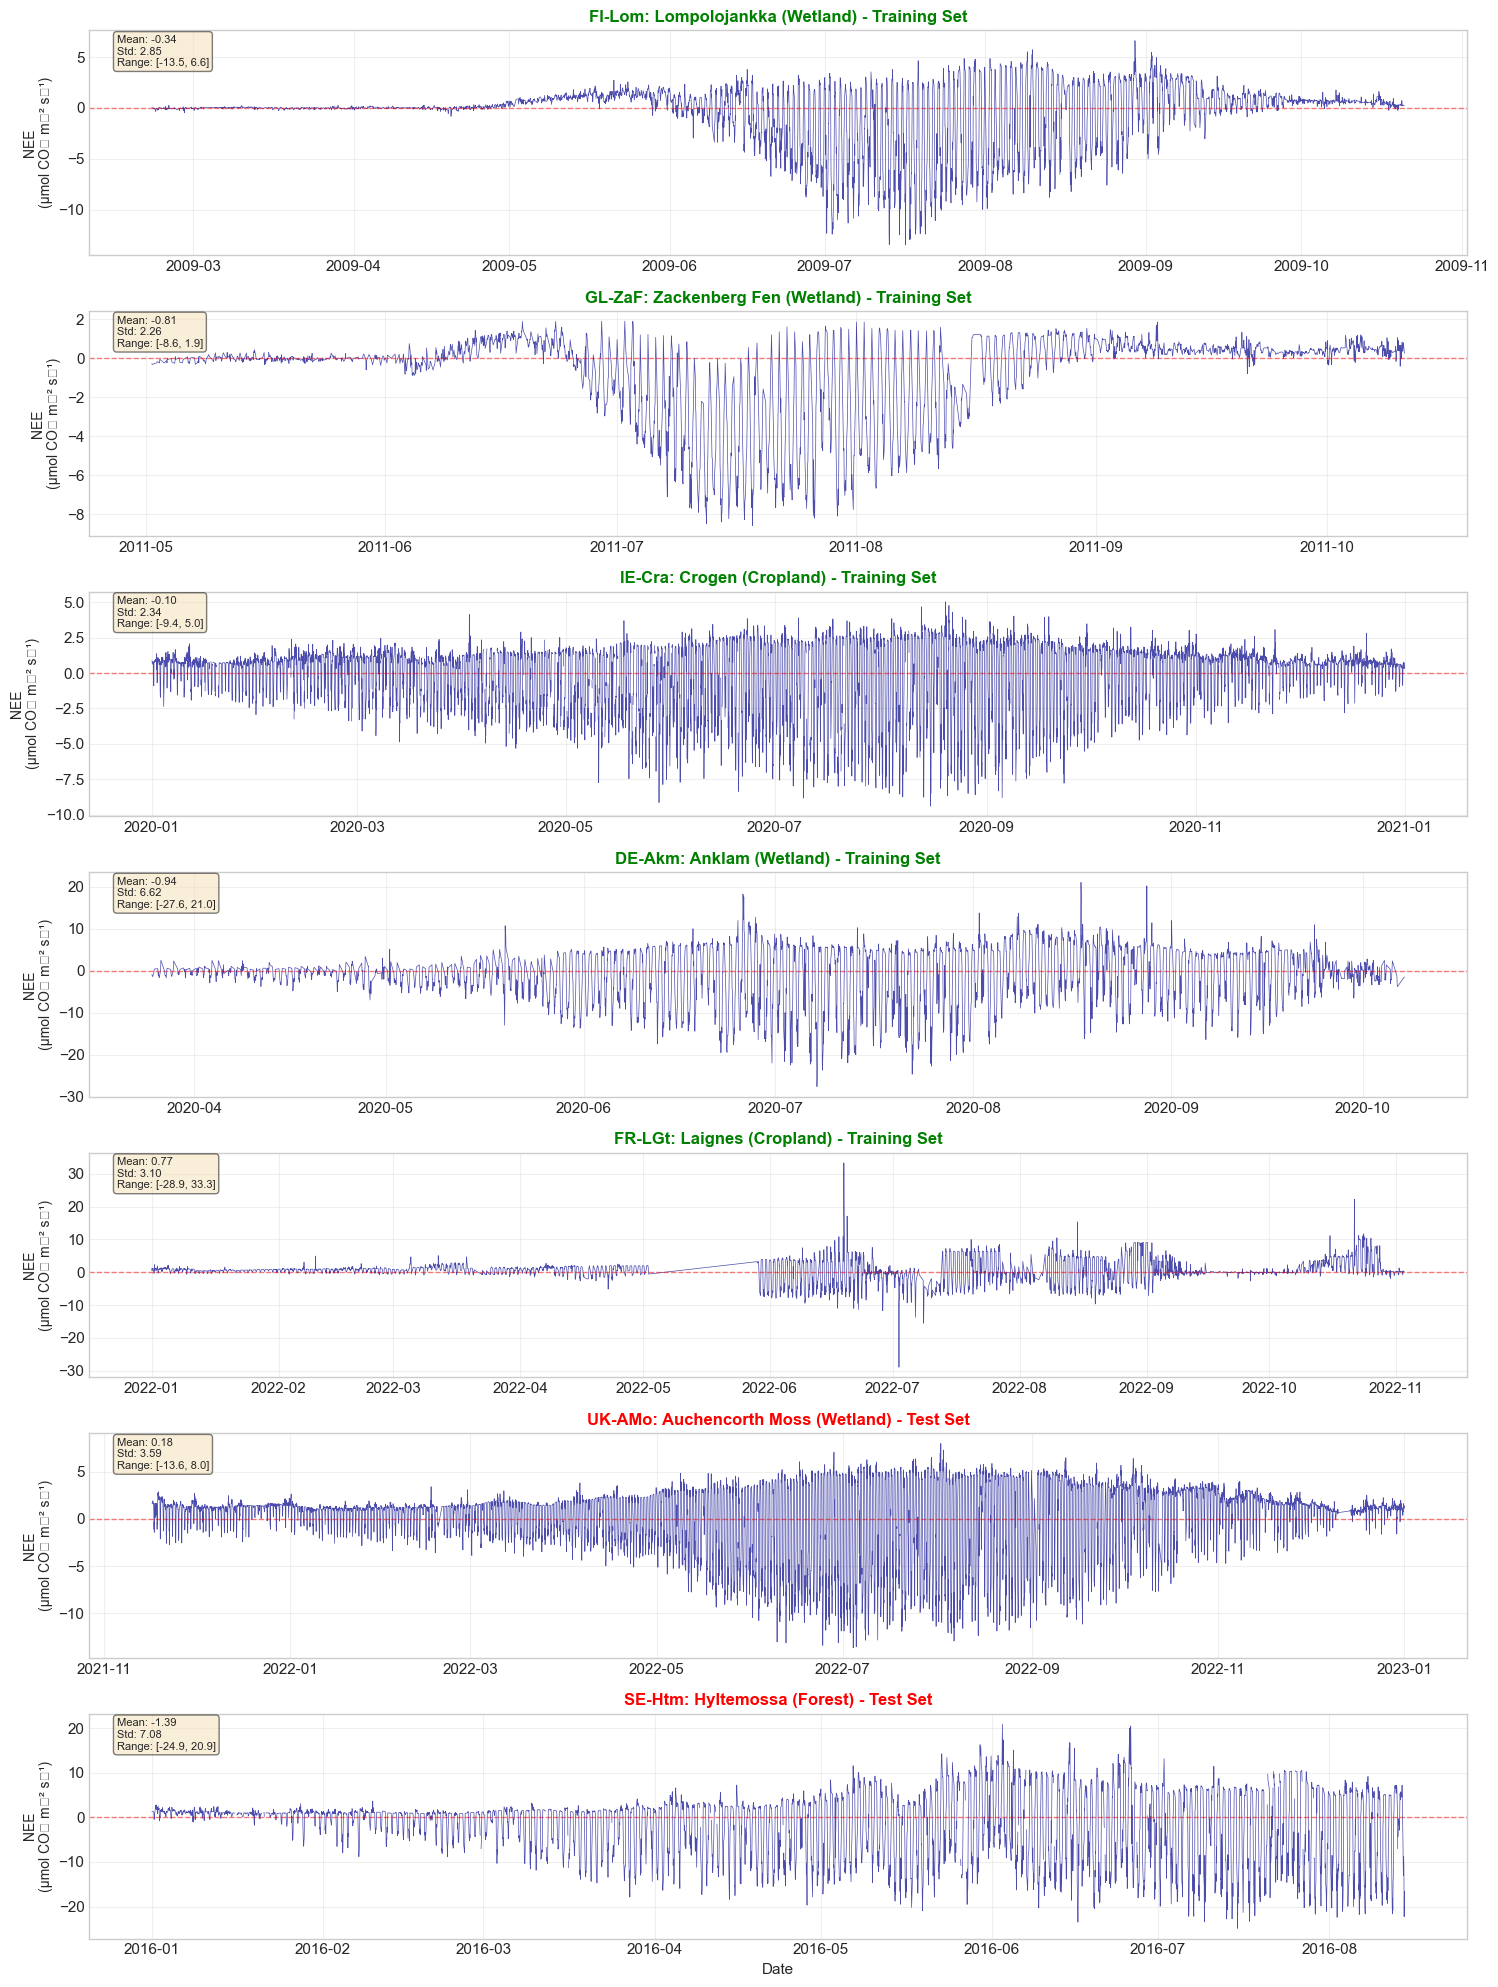

Figure saved: nee_timeseries_all_sites.png


In [15]:
fig, axes = plt.subplots(7, 1, figsize=(15, 20), sharex=False)

for idx, (code, info) in enumerate(data.items()):
    df = info['df']
    ax = axes[idx]

    if 'NEE_VUT_REF' in df.columns:
        nee = df['NEE_VUT_REF']
        ax.plot(df.index, nee, linewidth=0.5, alpha=0.7, color='darkblue')
        ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)

        split_color = 'red' if info['split'] == 'Test' else 'green'
        ax.set_title(
            f"{code}: {info['name']} ({info['ecosystem']}) "
            f"- {info['split']} Set",
            fontsize=12, fontweight='bold', color=split_color,
        )
        ax.set_ylabel('NEE\n(\u03bcmol CO\u2082 m\u207b\u00b2 s\u207b\u00b9)',
                       fontsize=10)
        ax.grid(True, alpha=0.3)

        stats_text = (
            f"Mean: {nee.mean():.2f}\n"
            f"Std: {nee.std():.2f}\n"
            f"Range: [{nee.min():.1f}, {nee.max():.1f}]"
        )
        ax.text(
            0.02, 0.98, stats_text, transform=ax.transAxes,
            verticalalignment='top', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
        )

axes[-1].set_xlabel('Date', fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / 'nee_timeseries_all_sites.png', dpi=300, bbox_inches='tight')
plt.savefig(FIG_DIR / 'nee_timeseries_all_sites.pdf', bbox_inches='tight')
plt.show()
print('Figure saved: nee_timeseries_all_sites.png')

## 4. Diurnal NEE Patterns by Ecosystem

Comparing day-night carbon exchange patterns across ecosystems. Photosynthesis drives NEE negative during daytime; respiration drives it positive at night.

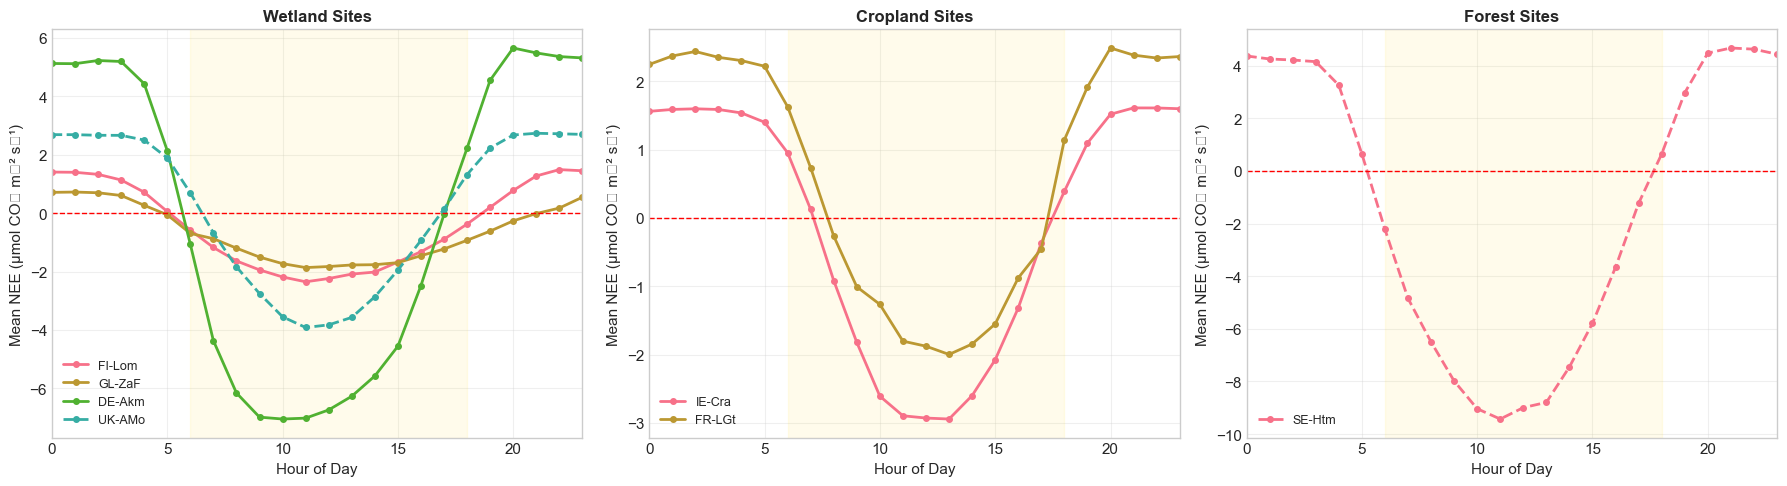

Figure saved: diurnal_patterns_by_ecosystem.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ecosystems = {'Wetland': [], 'Cropland': [], 'Forest': []}

for code, info in data.items():
    df = info['df']
    if 'NEE_VUT_REF' in df.columns:
        df_clean = df[['NEE_VUT_REF']].copy()
        df_clean['hour'] = df_clean.index.hour
        hourly_mean = df_clean.groupby('hour')['NEE_VUT_REF'].mean()
        ecosystems[info['ecosystem']].append((code, hourly_mean))

for idx, (eco_type, sites_data) in enumerate(ecosystems.items()):
    ax = axes[idx]

    for code, hourly_mean in sites_data:
        style = '--' if data[code]['split'] == 'Test' else '-'
        ax.plot(
            hourly_mean.index, hourly_mean.values,
            marker='o', linestyle=style, label=code,
            linewidth=2, markersize=4,
        )

    ax.axhline(y=0, color='red', linestyle='--', linewidth=1)
    ax.axvspan(6, 18, alpha=0.08, color='gold')
    ax.set_xlabel('Hour of Day', fontsize=11)
    ax.set_ylabel('Mean NEE (\u03bcmol CO\u2082 m\u207b\u00b2 s\u207b\u00b9)',
                   fontsize=11)
    ax.set_title(f'{eco_type} Sites', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    ax.set_xlim(0, 23)

plt.tight_layout()
plt.savefig(FIG_DIR / 'diurnal_patterns_by_ecosystem.png', dpi=300, bbox_inches='tight')
plt.savefig(FIG_DIR / 'diurnal_patterns_by_ecosystem.pdf', bbox_inches='tight')
plt.show()
print('Figure saved: diurnal_patterns_by_ecosystem.png')

## 5. Statistical Comparison Across Sites

Summary statistics and distributions of NEE by site.

In [17]:
# NEE statistics table
stat_rows = []
for code, info in data.items():
    df = info['df']
    if 'NEE_VUT_REF' in df.columns:
        nee = df['NEE_VUT_REF'].dropna()
        stat_rows.append({
            'Site': code,
            'Ecosystem': info['ecosystem'],
            'Split': info['split'],
            'Mean': f"{nee.mean():.3f}",
            'Std': f"{nee.std():.3f}",
            'Min': f"{nee.min():.3f}",
            'Q25': f"{nee.quantile(0.25):.3f}",
            'Median': f"{nee.median():.3f}",
            'Q75': f"{nee.quantile(0.75):.3f}",
            'Max': f"{nee.max():.3f}",
            'Skew': f"{nee.skew():.3f}",
        })

display(pd.DataFrame(stat_rows))

,Site,Ecosystem,Split,Mean,Std,Min,Q25,Median,Q75,Max,Skew
0,FI-Lom,Wetland,Training,-0.336,2.853,-13.476,-0.164,0.103,1.122,6.621,-1.607
1,GL-ZaF,Wetland,Training,-0.809,2.259,-8.583,-1.488,0.103,0.542,1.907,-1.500
2,IE-Cra,Cropland,Training,-0.104,2.336,-9.392,-1.457,0.771,1.441,5.030,-1.172
3,DE-Akm,Wetland,Training,-0.941,6.617,-27.580,-4.760,-0.081,4.505,21.025,-0.705
4,FR-LGt,Cropland,Training,0.766,3.100,-28.940,-0.164,0.670,1.739,33.279,0.023
5,UK-AMo,Wetland,Test,0.181,3.588,-13.645,-1.352,1.240,2.275,7.995,-1.204
6,SE-Htm,Forest,Test,-1.388,7.082,-24.887,-5.900,0.925,2.386,20.916,-0.624


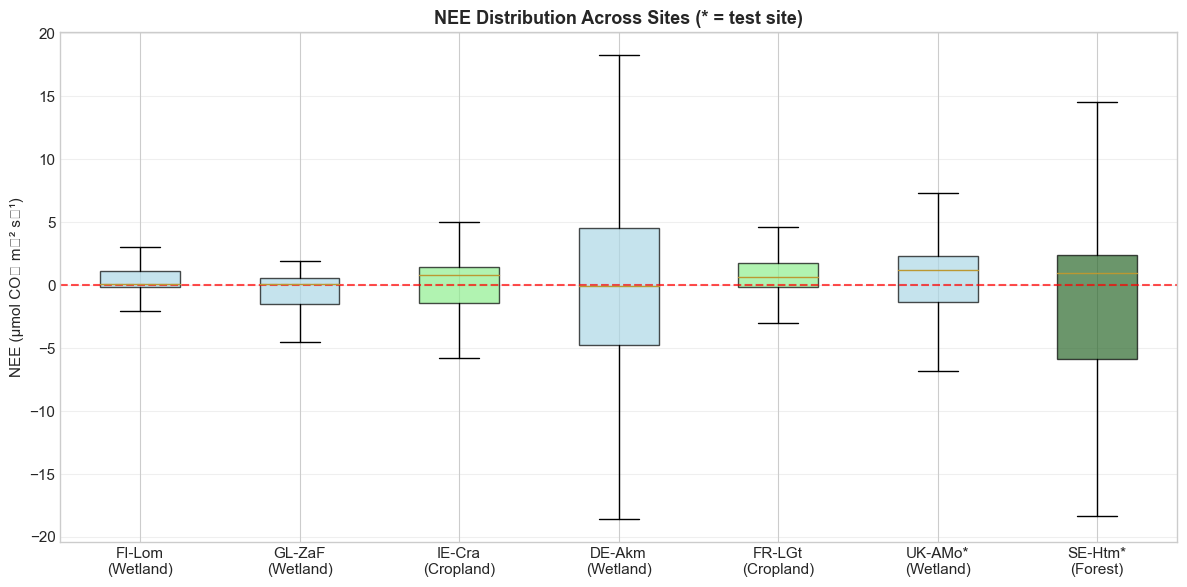

Figure saved: nee_distribution_boxplot.png


In [18]:
# Boxplot comparison
fig, ax = plt.subplots(figsize=(12, 6))

nee_data = []
labels = []
colors = []

color_map = {'Wetland': 'lightblue', 'Cropland': 'lightgreen', 'Forest': '#2d6a2d'}

for code, info in data.items():
    df = info['df']
    if 'NEE_VUT_REF' in df.columns:
        nee_data.append(df['NEE_VUT_REF'].dropna().values)
        marker = '*' if info['split'] == 'Test' else ''
        labels.append(f"{code}{marker}\n({info['ecosystem']})")
        colors.append(color_map[info['ecosystem']])

bp = ax.boxplot(nee_data, labels=labels, patch_artist=True, showfliers=False)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax.set_ylabel('NEE (\u03bcmol CO\u2082 m\u207b\u00b2 s\u207b\u00b9)', fontsize=11)
ax.set_title(
    'NEE Distribution Across Sites (* = test site)',
    fontsize=13, fontweight='bold',
)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIG_DIR / 'nee_distribution_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: nee_distribution_boxplot.png')

## 6. Feature Correlations (Example Site: UK-AMo)

Analyzing relationships between meteorological variables and NEE at the UK-AMo test site.

Available features for correlation: 11


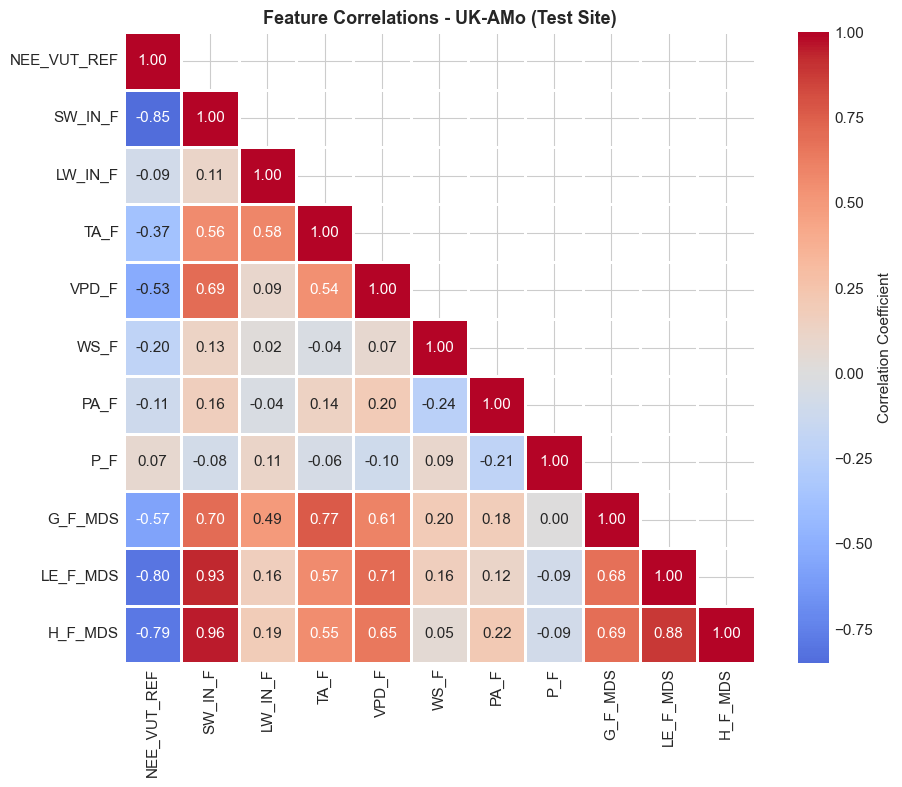

Figure saved: correlation_heatmap_UK-AMo.png


In [19]:
df_ukamo = data['UK-AMo']['df']

# Select key meteorological variables that are likely present
candidate_vars = [
    'NEE_VUT_REF', 'SW_IN_F', 'LW_IN_F', 'TA_F', 'VPD_F',
    'WS_F', 'PA_F', 'P_F', 'G_F_MDS', 'LE_F_MDS', 'H_F_MDS',
]
available_vars = [v for v in candidate_vars if v in df_ukamo.columns]
print(f'Available features for correlation: {len(available_vars)}')

corr_df = df_ukamo[available_vars].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1)
sns.heatmap(
    corr_df, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, square=True, linewidths=1, mask=mask,
    cbar_kws={'label': 'Correlation Coefficient'},
)
plt.title('Feature Correlations - UK-AMo (Test Site)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'correlation_heatmap_UK-AMo.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: correlation_heatmap_UK-AMo.png')

In [20]:
# NEE correlation ranking across all sites
print('NEE_VUT_REF correlations with key features per site:')
print('=' * 70)

key_features = ['SW_IN_F', 'TA_F', 'VPD_F', 'WS_F']
corr_rows = []

for code, info in data.items():
    df = info['df']
    if 'NEE_VUT_REF' not in df.columns:
        continue
    
    row = {'Site': code, 'Ecosystem': info['ecosystem']}
    for feat in key_features:
        if feat in df.columns:
            row[feat] = df[['NEE_VUT_REF', feat]].corr().iloc[0, 1]
        else:
            row[feat] = np.nan
    corr_rows.append(row)

corr_table = pd.DataFrame(corr_rows).set_index('Site')

# FIX: Only apply formatting to numeric columns
numeric_cols = corr_table.select_dtypes(include=[np.number]).columns.tolist()

display(
    corr_table.style
    .background_gradient(cmap='coolwarm', axis=None, subset=numeric_cols)
    .format('{:.3f}', subset=numeric_cols, na_rep='-')
)

NEE_VUT_REF correlations with key features per site:


,Ecosystem,SW_IN_F,TA_F,VPD_F,WS_F
Site,,,,,
FI-Lom,Wetland,-0.603,-0.305,-0.521,-0.092
GL-ZaF,Wetland,-0.503,-0.586,-0.494,0.105
IE-Cra,Cropland,-0.810,-0.369,-0.549,-0.243
DE-Akm,Wetland,-0.758,-0.290,-0.448,-
FR-LGt,Cropland,-0.665,-0.274,-0.482,-0.070
UK-AMo,Wetland,-0.849,-0.370,-0.531,-0.199
SE-Htm,Forest,-0.803,-0.222,-0.374,-0.225


## 7. Train vs Test Site Comparison

How similar are the test sites to the training distribution? This is critical for cross-site generalization.

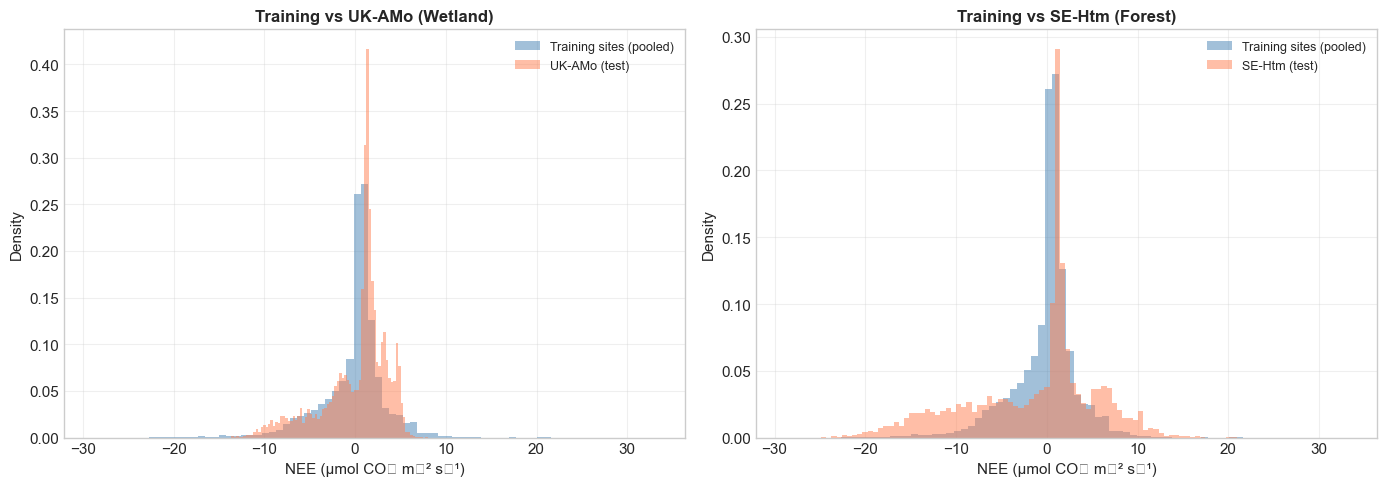

Figure saved: train_vs_test_distribution.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# NEE distribution: train sites vs test sites
train_nee = pd.concat(
    [info['df']['NEE_VUT_REF'].dropna()
     for code, info in data.items()
     if info['split'] == 'Training' and 'NEE_VUT_REF' in info['df'].columns]
)

for ax_idx, test_site in enumerate(['UK-AMo', 'SE-Htm']):
    ax = axes[ax_idx]
    test_nee = data[test_site]['df']['NEE_VUT_REF'].dropna()

    ax.hist(train_nee.values, bins=80, density=True, alpha=0.5,
            color='steelblue', label='Training sites (pooled)')
    ax.hist(test_nee.values, bins=80, density=True, alpha=0.5,
            color='coral', label=f'{test_site} (test)')

    ax.set_xlabel('NEE (\u03bcmol CO\u2082 m\u207b\u00b2 s\u207b\u00b9)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(
        f'Training vs {test_site} ({data[test_site]["ecosystem"]})',
        fontsize=12, fontweight='bold',
    )
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'train_vs_test_distribution.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: train_vs_test_distribution.png')

## 8. Key Findings

### Data Quality
- All 7 sites loaded successfully
- Training: 5 sites (23,899 sequences), Test: 2 sites (14,062 sequences)
- NEE missing data handled through gap-filling pipeline

### Ecosystem Differences
- **Wetlands** (UK-AMo, FI-Lom, GL-ZaF, DE-Akm): Weak diurnal patterns, respiration-dominated
- **Forest** (SE-Htm): Strong diurnal cycle with clear photosynthesis signal
- **Croplands** (IE-Cra, FR-LGt): Moderate diurnal patterns

### Site Characteristics
- **UK-AMo (Test)**: Minimal diurnal variation (~0.1 \u03bcmol/m\u00b2/s day-night diff)
- **SE-Htm (Test)**: Strong diurnal variation (~9.4 \u03bcmol/m\u00b2/s day-night diff)
- This explains differential model performance (R\u00b2=0.38 vs R\u00b2=0.75)

### Implications for Modeling
The fundamental ecosystem differences identified here explain why:
1. Zero-shot TEMPO performed well on SE-Htm (forest) but poorly on UK-AMo (wetland)
2. Fine-tuning helped wetland but hurt forest (ecosystem-specific adaptation)
3. All models struggled more with wetland prediction (inherently weaker patterns)

In [22]:
from IPython.display import display, Markdown

display(Markdown("""
---
### Summary

| Category | Details |
|----------|---------|
| Sites loaded | 7 EC tower sites (5 train / 2 test) |
| Figures | NEE time series, diurnal patterns, distributions, correlations |
| Output directory | `/figures/` |

### Key Findings
- **Wetlands** (UK-AMo, FI-Lom, GL-ZaF, DE-Akm): weak diurnal signal, respiration-dominated
- **Forest** (SE-Htm): strong photosynthesis signal with clear day–night cycle (~9.4 µmol/m²/s amplitude)
- **Croplands** (IE-Cra, FR-LGt): moderate, seasonally structured patterns
- **Cross-site gap**: UK-AMo shows minimal diurnal variation — explains R²=0.38 vs SE-Htm R²=0.75 in downstream modelling
---
"""))



---
### Summary

| Category | Details |
|----------|---------|
| Sites loaded | 7 EC tower sites (5 train / 2 test) |
| Figures | NEE time series, diurnal patterns, distributions, correlations |
| Output directory | `/figures/` |

### Key Findings
- **Wetlands** (UK-AMo, FI-Lom, GL-ZaF, DE-Akm): weak diurnal signal, respiration-dominated
- **Forest** (SE-Htm): strong photosynthesis signal with clear day–night cycle (~9.4 µmol/m²/s amplitude)
- **Croplands** (IE-Cra, FR-LGt): moderate, seasonally structured patterns
- **Cross-site gap**: UK-AMo shows minimal diurnal variation — explains R²=0.38 vs SE-Htm R²=0.75 in downstream modelling
---
